In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import json
import pandas
import geopandas
from pathlib import Path
from datetime import datetime, timedelta
import openeo
import uuid
import pystac_client
import matplotlib.pyplot as plt

In [2]:
# Platform configuration
ISO_8601 = '%Y-%m-%dT%H:%M:%SZ'

# STAC service URL
#STAC_URL="https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com" # Dev instance
STAC_URL="https://stac-fastapi-pgstac-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com" # Staging

username = os.environ["OPENEO_USERNAME"]
password = os.environ["OPENEO_PASSWORD"]

# OpenEO service URL
#OPENEO_URL="https://tensorlakehouse-openeo-driver-nasageospatial-dev.cash.sl.cloud9.ibm.com" # Dev instance
OPENEO_URL="https://tensorlakehouse-openeo-driver-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com" # Staging

# authenticate_oidc_resource_owner_password_credentials for OPENEO_URL="https://tensorlakehouse-openeo-driver-nasageospatial-dev.cash.sl.cloud9.ibm.com"
APPID_USERNAME = os.environ["APPID_USERNAME"]
APPID_PASSWORD = os.environ["APPID_PASSWORD"]
OPENEO_AUTH_CLIENT_ID = os.environ["OPENEO_AUTH_CLIENT_ID"]
OPENEO_AUTH_CLIENT_SECRET = os.environ["OPENEO_AUTH_CLIENT_SECRET"]

# create a data dir if it does not exist
data_dir = Path.cwd() / "data" 
if not data_dir.exists():
    data_dir.mkdir()

print(f"OPENEO_URL: {OPENEO_URL}")
print(f"STAC_URL:   {STAC_URL}")

OPENEO_URL: https://tensorlakehouse-openeo-driver-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com
STAC_URL:   https://stac-fastapi-pgstac-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com


In [3]:
# OpenEO Authentification
connection = openeo.connect(OPENEO_URL)
connection.authenticate_oidc_resource_owner_password_credentials(
    username=APPID_USERNAME,
    password=APPID_PASSWORD,
    client_id=OPENEO_AUTH_CLIENT_ID,
    client_secret=OPENEO_AUTH_CLIENT_SECRET,
    provider_id="app_id",
    store_refresh_token=False,
)

<Connection to 'https://tensorlakehouse-openeo-driver-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com/openeo/1.2/' with OidcBearerAuth>

In [4]:
# STAC catalogue
catalog = pystac_client.Client.open(STAC_URL)
collections = catalog.get_all_collections()
cl_id = [c.id for c in collections]
for c in cl_id:
    print(f"collection: {c}")

collection: esa-sentinel-2A-msil1c
collection: HLSS30
collection: global-weather-era5
collection: dev_ne_10m_admin_0_countries
collection: gedi-l2a
collection: atmospheric-era5
collection: test-gedi-l2a
collection: atmospheric-weather-era5
collection: ds335-sentinel1
collection: sentinel-1-grd
collection: dev_kaggle_wildfire
collection: ibm-eis-ga-1-esa-sentinel-2-l2a
collection: Radar
collection: Radar-10min
collection: tasmax-rcp85-land-cpm-uk-2.2km
collection: ibm-eis-ga-1-era5-pr-wdc
collection: HLSL30_version2
collection: vector-osm-power
collection: vector-osm-building
collection: vector-osm-poi
collection: vector-osm-road
collection: vector-osm-natural
collection: vector-osm-railway
collection: vector-osm-boundary
collection: vector-osm-landuse
collection: vector-osm-waterway
collection: dev-hsi-radar-10min


In [5]:
# Query Parameters

# OpenEO notation
#spatial_extent={"west": -73.96, "south": 41.12, "east": -73.9, "north": 41.18}  # Rockland Lake
spatial_extent={"west": 2.26, "south": 48.84, "east": 2.32, "north": 48.90}  # Paris arc de triomphe

# Temporal
#year = 2023
dt_start = datetime(1970, 1, 1)
start = dt_start.strftime(ISO_8601)
dt_end = datetime(2030, 1, 1)-timedelta(seconds=1)
end = dt_end.strftime(ISO_8601)
# STAC notation
time_range = f"{start}/{end}"
# OpenEO notation
temporal_extent = [start, end]

# Vectordata output format
output_format = "Parquet"

print(f"time_range:     {time_range}")
print(f"output_format:  {output_format}")

time_range:     1970-01-01T00:00:00Z/2029-12-31T23:59:59Z
output_format:  Parquet


In [6]:
# Collection: method "describe_collection" shows description and available bands/timestamps
collection_id = "vector-osm-road"
collection = catalog.get_collection(collection_id)
bands = collection.extra_fields['cube:dimensions']['bands']['values']
connection.describe_collection(collection_id)

{'cube:dimensions': {'bands': {'type': 'bands',
   'values': ['address',
    'admin_level',
    'aerialway',
    'aeroway',
    'amenity',
    'barrier',
    'boundary',
    'building',
    'craft',
    'emergency',
    'geological',
    'highway',
    'historic',
    'is_in',
    'land_area',
    'landuse',
    'leisure',
    'man_made',
    'military',
    'name',
    'name:en',
    'natural',
    'office',
    'osm_id',
    'osm_node_id',
    'osm_relation_id',
    'osm_version',
    'osm_way_id',
    'other_tags',
    'place',
    'power',
    'public_transport',
    'pyogrio_layer',
    'railway',
    'ref',
    'route',
    'shop',
    'sport',
    'tourism',
    'type',
    'waterway',
    'z_order']},
  'osm_timestamp': {'extent': ['2006-03-22T20:54:52+00:00',
    '2024-05-19T23:59:51+00:00'],
   'type': 'temporal'}},
 'deprecated': False,
 'description': 'Open Street Map (OSM) Road network (non-nan "highway" key).',
 'extent': {'spatial': {'bbox': [[-180,
     -90,
     179.9999999999999,
     89.9999999999999]]},
  'temporal': {'interval': [['2006-03-22T20:54:52Z',
     '2024-05-19T23:59:51Z']]}},
 'id': 'vector-osm-road',
 'keywords': [],
 'license': 'Unknown',
 'links': [{'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/collections/vector-osm-road/items',
   'rel': 'items',
   'type': 'application/geo+json'},
  {'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/',
   'rel': 'parent',
   'type': 'application/json'},
  {'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/',
   'rel': 'root',
   'title': 'stac-fastapi',
   'type': 'application/json'},
  {'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/collections/vector-osm-road',
   'rel': 'self',
   'type': 'application/json'}],
 'providers': [{'description': 'Producers of awesome spatiotemporal assets',
   'name': 'IBM',
   'roles': ['producer', 'processor'],
   'url': 'https://www.ibm.com'}],
 'stac_extensions': ['https://stac-extensions.github.io/datacube/v2.2.0/schema.json'],
 'stac_version': '1.0.0',
 'summaries': {},
 'title': 'OSM Road',
 'type': 'Collection',
 'version': ''}

In [7]:
%%time
# Compute and Download
query_bands = bands
print("query_bands:", query_bands)

datacube: openeo.DataCube = connection.load_collection(
    collection_id=collection_id,
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=query_bands,
)
datacube = datacube.save_result(format=output_format)
filename = uuid.uuid4().hex + "." + output_format.lower()
path = data_dir / filename
datacube.download(outputfile=path)
print(path)

# Read Parquet using geopandas
gdf_road = geopandas.read_parquet(path).reset_index(drop=True)
gdf_road.dropna(axis=1).tail(2)

query_bands: ['address', 'admin_level', 'aerialway', 'aeroway', 'amenity', 'barrier', 'boundary', 'building', 'craft', 'emergency', 'geological', 'highway', 'historic', 'is_in', 'land_area', 'landuse', 'leisure', 'man_made', 'military', 'name', 'name:en', 'natural', 'office', 'osm_id', 'osm_node_id', 'osm_relation_id', 'osm_version', 'osm_way_id', 'other_tags', 'place', 'power', 'public_transport', 'pyogrio_layer', 'railway', 'ref', 'route', 'shop', 'sport', 'tourism', 'type', 'waterway', 'z_order']


Preflight process graph validation failed: [403] AuthenticationSchemeInvalid: Authentication method not supported. (ref: r-240612ef093546f79116dd054bdaeaa5)


C:\Users\2D1245897\software\overviews\vectorstore\examples\data\6c72ccdafe4847b6add796ed1f4af820.parquet
CPU times: total: 250 ms
Wall time: 12.6 s


,highway,osm_version,other_tags,geometry,osm_id,osm_timestamp,pyogrio_layer
40221,crossing,6,"{""crossing"": ""uncontrolled"", ""crossing:island""...",POINT (2.31917 48.89982),n6052944785,2021-12-19 19:07:33+00:00,points
40222,residential,13,"{""cycleway"": ""no"", ""lit"": ""yes"", ""maxspeed"": ""...","LINESTRING (2.31931 48.90000, 2.31923 48.89990...",r32746909,2021-09-15 01:30:31+00:00,lines


In [8]:
# Drop points (such as stop signs, traffic lights, or turning circles
print('pyogrio_layer values found in gdf_road', sorted(set(gdf_road['pyogrio_layer'])))
print('filtering out points')
gdf_road = gdf_road[gdf_road['pyogrio_layer']!='points'].reset_index(drop=True)
gdf_road.dropna(axis=1, how='all').tail(2)

pyogrio_layer values found in gdf_road ['lines', 'multipolygons', 'other_relations', 'points']
filtering out points


,highway,osm_version,other_tags,geometry,emergency,admin_level,osm_way_id,shop,name,building,...,osm_id,ref,osm_timestamp,barrier,man_made,public_transport,pyogrio_layer,leisure,historic,type
29561,service,4,"{""service"": ""driveway"", ""vehicle"": ""private""}","LINESTRING (2.31777 48.89975, 2.31767 48.89982...",<NA>,<NA>,<NA>,<NA>,Passage Nivert,<NA>,...,r317854654,<NA>,2019-03-10 21:10:51+00:00,<NA>,<NA>,<NA>,lines,<NA>,<NA>,<NA>
29562,residential,13,"{""cycleway"": ""no"", ""lit"": ""yes"", ""maxspeed"": ""...","LINESTRING (2.31931 48.90000, 2.31923 48.89990...",<NA>,<NA>,<NA>,<NA>,Rue Floréal,<NA>,...,r32746909,<NA>,2021-09-15 01:30:31+00:00,<NA>,<NA>,<NA>,lines,<NA>,<NA>,<NA>


In [9]:
# other_tags contains a json-encoded dictionary. Convert to python dictionary to access the keys.
gdf_road['other_tags'] = gdf_road['other_tags'].apply(lambda x: json.loads(x))
gdf_road['other_tags']

0                                  {'footway': 'sidewalk'}
1            {'footway': 'sidewalk', 'surface': 'asphalt'}
2        {'cycleway': 'opposite', 'lit': 'yes', 'maxspe...
3                                  {'footway': 'sidewalk'}
4                {'lit': 'no', 'surface': 'paving_stones'}
                               ...                        
29558    {'lit': 'yes', 'maxspeed': '30', 'oneway': 'no...
29559    {'bicycle': 'yes', 'dual_carriageway': 'yes', ...
29560    {'cycleway': 'no', 'lanes': '4', 'lanes:backwa...
29561        {'service': 'driveway', 'vehicle': 'private'}
29562    {'cycleway': 'no', 'lit': 'yes', 'maxspeed': '...
Name: other_tags, Length: 29563, dtype: object

In [10]:
def get_tag(dict_col, tag):
    try:
        return dict_col[tag]
    except:
        return None

gdf_road['bicycle'] = gdf_road['other_tags'].apply(lambda x: get_tag(x, 'bicycle'))
gdf_bicycle = gdf_road[(gdf_road['highway']=='cycleway') | (
    (gdf_road['bicycle'].notnull()) & (gdf_road['bicycle']!='no')
)].reset_index(drop=True)
gdf_bicycle.dropna(axis=1, how='all').tail(2)

,highway,osm_version,other_tags,geometry,emergency,osm_way_id,name,osm_relation_id,z_order,osm_id,ref,osm_timestamp,pyogrio_layer,type,bicycle
940,residential,1,"{'bicycle': 'yes', 'cycleway:left': 'lane', 'c...","LINESTRING (2.29665 48.89917, 2.29671 48.89920...",<NA>,<NA>,Rue de Neuilly,1228681611,3.0,r1228681611,<NA>,2023-12-04 16:52:17+00:00,lines,<NA>,yes
941,secondary,11,"{'bicycle': 'yes', 'dual_carriageway': 'yes', ...","LINESTRING (2.31895 48.89979, 2.31858 48.89981)",<NA>,<NA>,Boulevard du Bois le Prêtre,538779468,6.0,r538779468,D 110,2023-04-25 18:57:41+00:00,lines,<NA>,yes


In [11]:
# Collection: method "describe_collection" shows description and available bands/timestamps
collection_id = "vector-osm-building"
collection = catalog.get_collection(collection_id)
bands = collection.extra_fields['cube:dimensions']['bands']['values']
connection.describe_collection(collection_id)

{'cube:dimensions': {'bands': {'type': 'bands',
   'values': ['address',
    'admin_level',
    'aerialway',
    'aeroway',
    'amenity',
    'barrier',
    'boundary',
    'building',
    'craft',
    'emergency',
    'geological',
    'highway',
    'historic',
    'is_in',
    'land_area',
    'landuse',
    'leisure',
    'man_made',
    'military',
    'name',
    'name:en',
    'natural',
    'office',
    'osm_id',
    'osm_node_id',
    'osm_relation_id',
    'osm_version',
    'osm_way_id',
    'other_tags',
    'place',
    'power',
    'public_transport',
    'pyogrio_layer',
    'railway',
    'ref',
    'route',
    'shop',
    'sport',
    'tourism',
    'type',
    'waterway',
    'z_order']},
  'osm_timestamp': {'extent': ['2006-12-01T00:19:29+00:00',
    '2024-05-19T23:59:51+00:00'],
   'type': 'temporal'}},
 'deprecated': False,
 'description': 'Open Street Map (OSM) Buildings (non-nan "building" key).',
 'extent': {'spatial': {'bbox': [[-180,
     -90,
     179.9999999999999,
     89.9999999999999]]},
  'temporal': {'interval': [['2006-12-01T00:19:29Z',
     '2024-05-19T23:59:51Z']]}},
 'id': 'vector-osm-building',
 'keywords': [],
 'license': 'Unknown',
 'links': [{'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/collections/vector-osm-building/items',
   'rel': 'items',
   'type': 'application/geo+json'},
  {'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/',
   'rel': 'parent',
   'type': 'application/json'},
  {'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/',
   'rel': 'root',
   'title': 'stac-fastapi',
   'type': 'application/json'},
  {'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/collections/vector-osm-building',
   'rel': 'self',
   'type': 'application/json'}],
 'providers': [{'description': 'Producers of awesome spatiotemporal assets',
   'name': 'IBM',
   'roles': ['producer', 'processor'],
   'url': 'https://www.ibm.com'}],
 'stac_extensions': ['https://stac-extensions.github.io/datacube/v2.2.0/schema.json'],
 'stac_version': '1.0.0',
 'summaries': {},
 'title': 'OSM Building',
 'type': 'Collection',
 'version': ''}

In [12]:
%%time
# Compute and Download
query_bands = bands
print("query_bands:", query_bands)

datacube: openeo.DataCube = connection.load_collection(
    collection_id=collection_id,
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=query_bands,
)
datacube = datacube.save_result(format=output_format)
filename = uuid.uuid4().hex + "." + output_format.lower()
path = data_dir / filename
datacube.download(outputfile=path)
print(path)

# Read Parquet using geopandas
gdf_building = geopandas.read_parquet(path).reset_index(drop=True)
gdf_building.dropna(axis=1, how='all').tail(2)

Preflight process graph validation failed: [403] AuthenticationSchemeInvalid: Authentication method not supported. (ref: r-24061237de794825af57bd0a9ae94fb8)


query_bands: ['address', 'admin_level', 'aerialway', 'aeroway', 'amenity', 'barrier', 'boundary', 'building', 'craft', 'emergency', 'geological', 'highway', 'historic', 'is_in', 'land_area', 'landuse', 'leisure', 'man_made', 'military', 'name', 'name:en', 'natural', 'office', 'osm_id', 'osm_node_id', 'osm_relation_id', 'osm_version', 'osm_way_id', 'other_tags', 'place', 'power', 'public_transport', 'pyogrio_layer', 'railway', 'ref', 'route', 'shop', 'sport', 'tourism', 'type', 'waterway', 'z_order']
C:\Users\2D1245897\software\overviews\vectorstore\examples\data\6c720db31be3454b972533d11feea558.parquet
CPU times: total: 109 ms
Wall time: 16.3 s


,highway,osm_version,other_tags,geometry,emergency,power,craft,osm_way_id,shop,amenity,...,osm_timestamp,barrier,man_made,public_transport,tourism,office,pyogrio_layer,leisure,historic,type
33593,<NA>,4,"{""building:levels"": ""7""}","POLYGON ((2.31987 48.88008, 2.31995 48.88005, ...",<NA>,<NA>,<NA>,68285994,<NA>,<NA>,...,2023-08-25 06:25:16+00:00,<NA>,<NA>,<NA>,<NA>,<NA>,multipolygons,<NA>,<NA>,<NA>
33594,<NA>,3,{},"POLYGON ((2.31952 48.87992, 2.31946 48.87991, ...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,2023-08-25 06:25:15+00:00,<NA>,<NA>,<NA>,<NA>,<NA>,multipolygons,<NA>,<NA>,multipolygon


In [13]:
%%time
try:
    # Compute and Download
    
    # Collection
    collection_id = "dev_kaggle_wildfire"
    
    # List all the available bands (table columns)
    collection = catalog.get_collection(collection_id)
    print(collection.title)
    bands = collection.extra_fields['cube:dimensions']['bands']['values']
    #print('all bands:  ', bands)
    
    query_bands = bands
    print("query_bands:", query_bands)
    
    datacube: openeo.DataCube = connection.load_collection(
        collection_id=collection_id,
        spatial_extent=spatial_extent,
        temporal_extent=temporal_extent,
        bands=query_bands,
    )
    datacube = datacube.save_result(format=output_format)
    filename = uuid.uuid4().hex + "." + output_format.lower()
    path = data_dir / filename
    datacube.download(outputfile=path)
    print(path)
    
    # Read Parquet using geopandas
    gdf_wildfire = geopandas.read_parquet(path)
    gdf_wildfire.tail(2)
except:
    # Kaggle wildfire dataset only available in the US
    gdf_wildfire = geopandas.GeoDataFrame(pandas.DataFrame(columns=['geometry']), geometry='geometry')
    
gdf_wildfire

Kaggle Wildfire
query_bands: ['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID', 'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT', 'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID', 'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME', 'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY', 'FIPS_CODE', 'FIPS_NAME', 'Shape']


Preflight process graph validation failed: [403] AuthenticationSchemeInvalid: Authentication method not supported. (ref: r-2406122fa41f473b975a21e814eafd2b)


CPU times: total: 0 ns
Wall time: 1.54 s


,geometry


C:\cygwin64\tmp\ipykernel_78044\2881843354.py:4: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_wildfire.plot(ax=ax, color='maroon', edgecolor='red', alpha=.5) #, label='wildfires')
C:\cygwin64\tmp\ipykernel_78044\2881843354.py:5: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper right', fontsize=12)


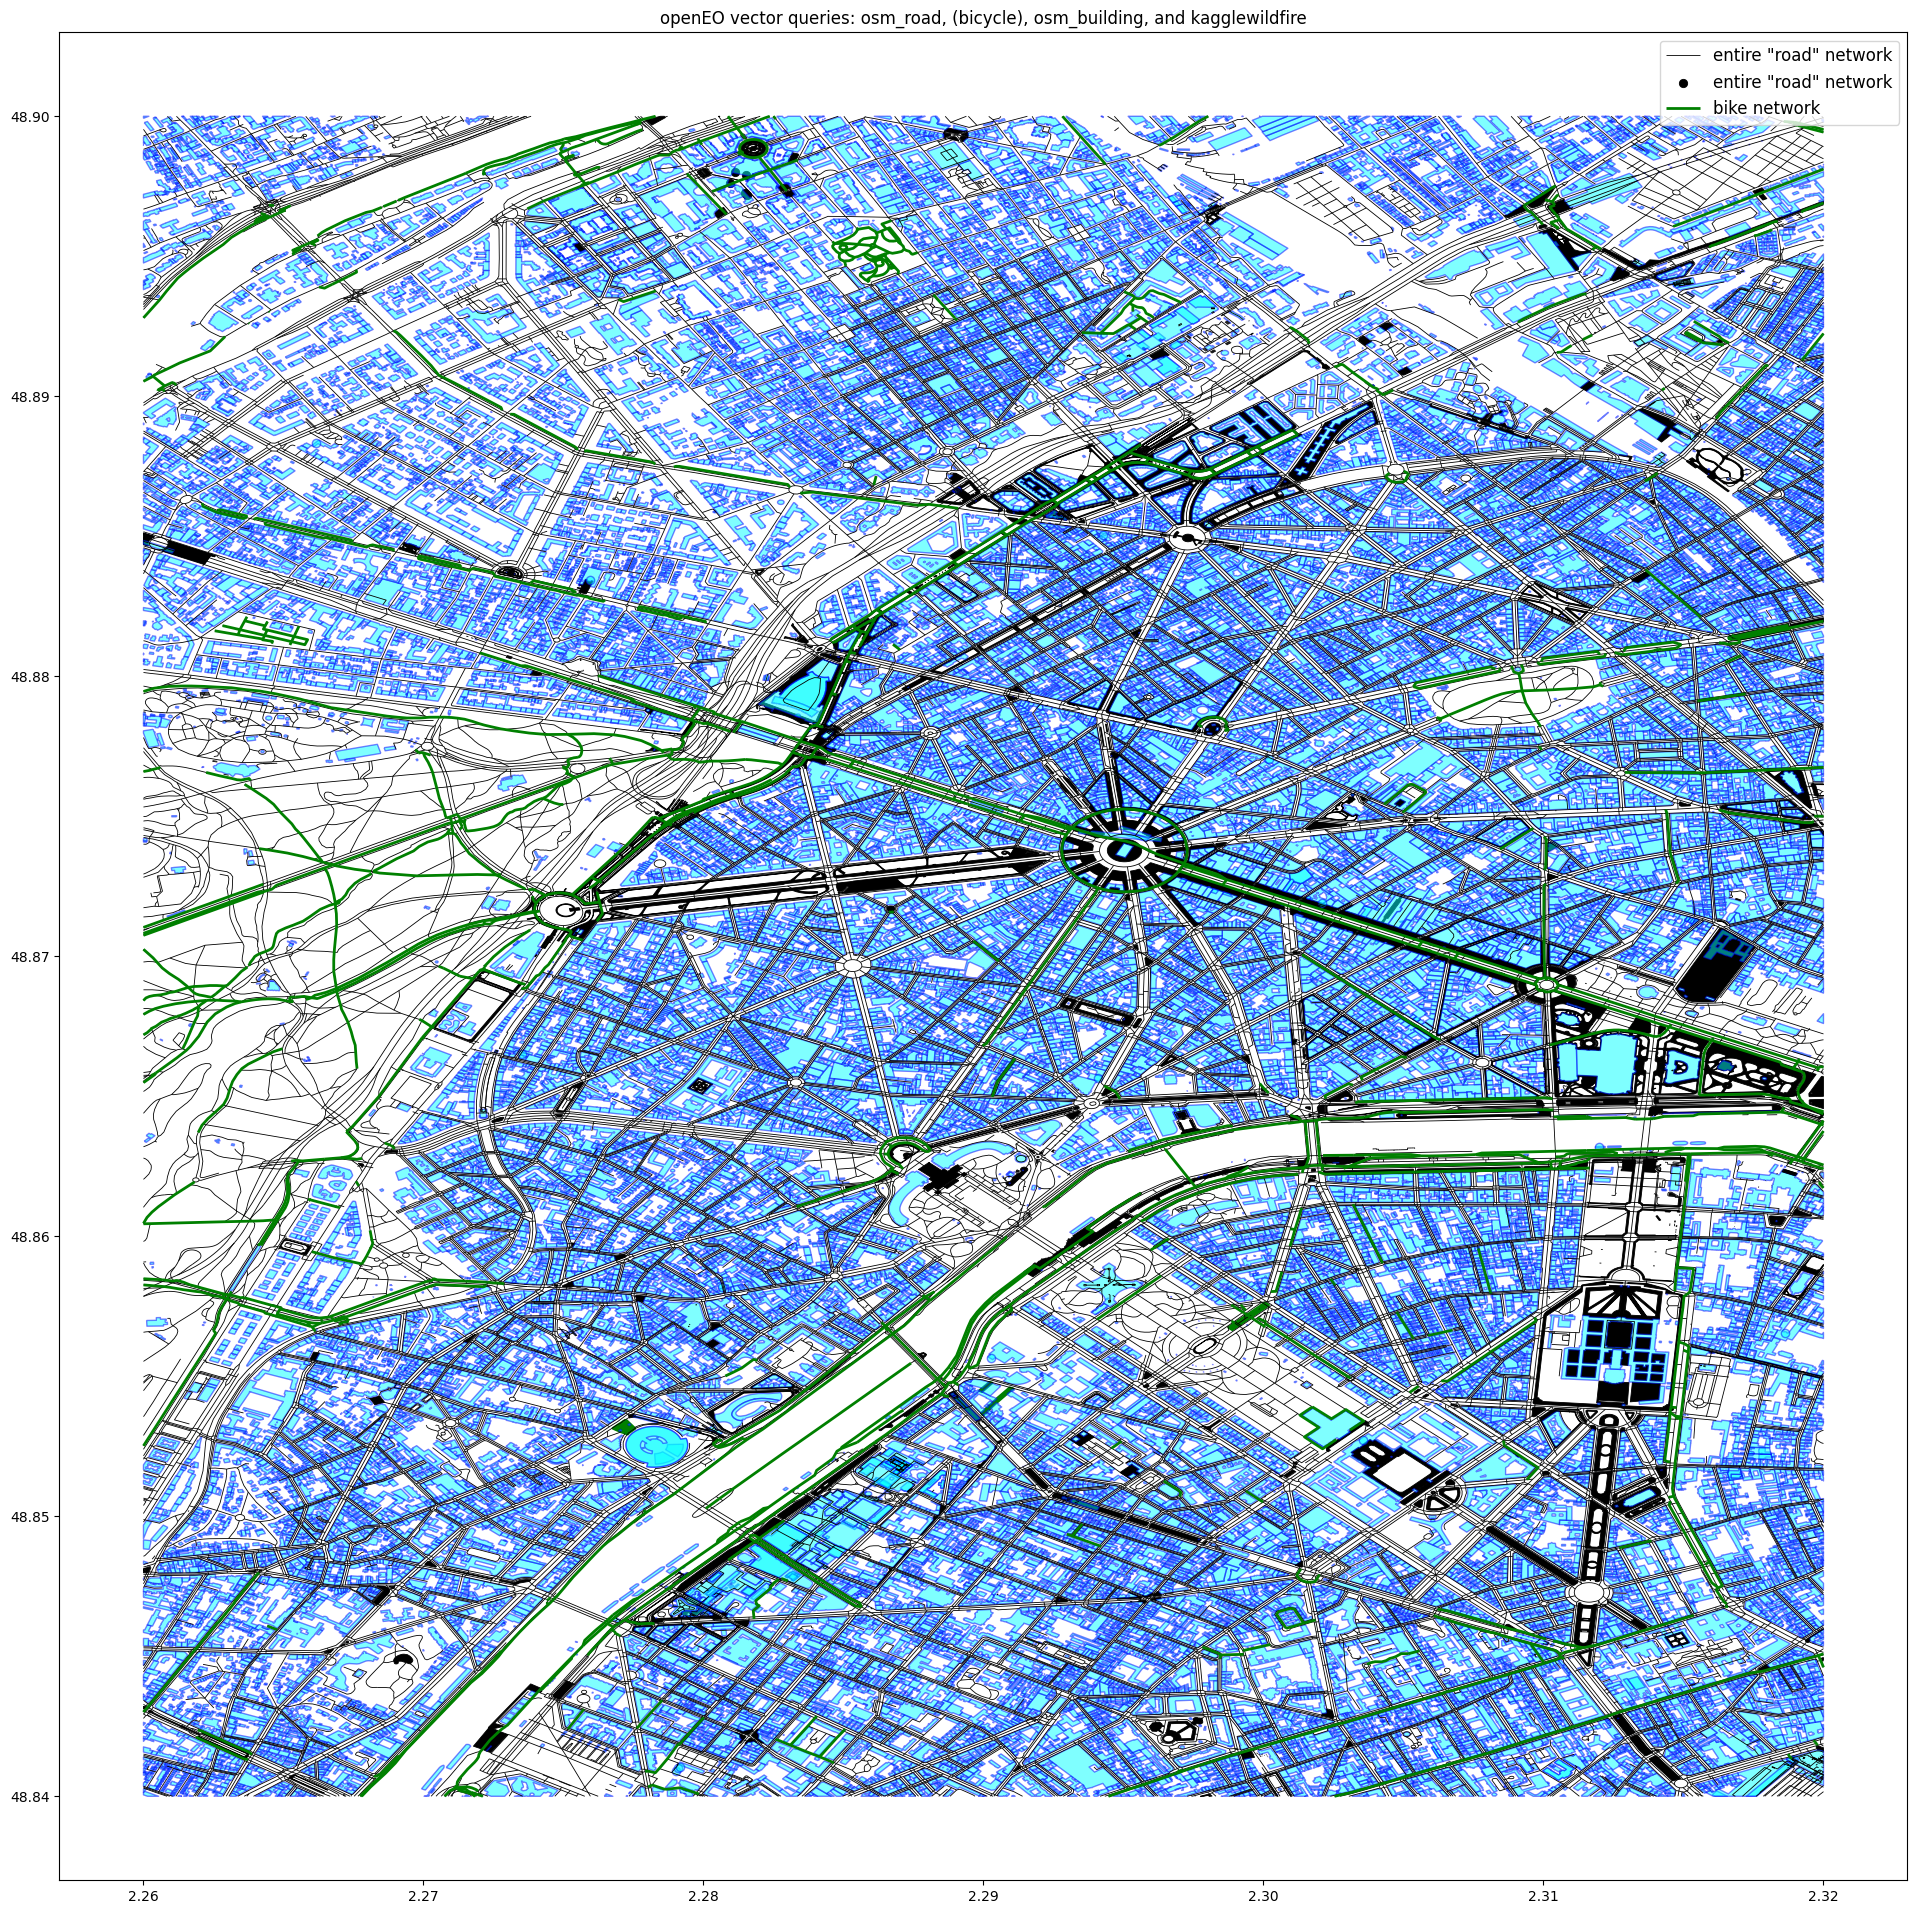

In [14]:
ax = gdf_road.plot(color='k', edgecolor='k', lw=.6, label='entire "road" network', figsize=(24,24))
gdf_bicycle.plot(ax=ax, color='green', edgecolor='green', lw=2, label='bike network')
gdf_building.plot(ax=ax, color='cyan', edgecolor='blue', alpha=.5) #, label='buildings')
gdf_wildfire.plot(ax=ax, color='maroon', edgecolor='red', alpha=.5) #, label='wildfires')
plt.legend(loc='upper right', fontsize=12)
plt.title('openEO vector queries: osm_road, (bicycle), osm_building, and kagglewildfire', fontsize=12)
plt.show()

## STAC

In [15]:
# Collection
collection_id = 'vector-osm-building'

# Search the Stac catalog collection for matching items
catalog = pystac_client.Client.open(STAC_URL)
bbox = [-180, -90, 180, 90]
limit=10000
search = catalog.search(collections=[collection_id], bbox=bbox, datetime=time_range, limit=limit)
items = search.item_collection().items
assert len(items)<limit

gdf_items = geopandas.GeoDataFrame.from_features(items)
try:
    gdf_items = gdf_items.sort_values(by='datetime').reset_index(drop=True)
    stac_sorted_timestamps = sorted(gdf_items["datetime"])
except:
    gdf_items = gdf_items.sort_values(by='start_datetime').reset_index(drop=True)
    stac_sorted_timestamps = sorted(gdf_items["start_datetime"])
    
stac_start = stac_sorted_timestamps[0]
stac_end = stac_sorted_timestamps[-1]

print(f"items found: {len(items)}")
print(f"stac_start:  {stac_start}")
print(f"stac_end:    {stac_end}")

gdf_items.tail(2)

items found: 812
stac_start:  2006-12-01T00:19:29Z
stac_end:    2017-05-12T19:30:09Z


,geometry,proj:epsg,end_datetime,cube:variables,start_datetime,cube:dimensions,datetime
810,"POLYGON ((88.61040 22.50064, 88.61038 22.50075...",4326,2024-04-30T16:37:22Z,"{'ref': {'type': 'data', 'unit': '', 'dimensio...",2015-01-31T21:39:55Z,"{'geometry': {'bbox': [88.5938291, 22.5006397,...",None
811,"POLYGON ((3.20899 6.67969, 3.18046 6.67969, 3....",4326,2024-05-19T21:30:21Z,"{'ref': {'type': 'data', 'unit': '', 'dimensio...",2017-05-12T19:30:09Z,"{'geometry': {'bbox': [3.1640627, 6.6796875, 3...",None


In [16]:
items[0]

<Item id=16d5392cdc1c41bd8be3e3fe35897fdb>

<Axes: >

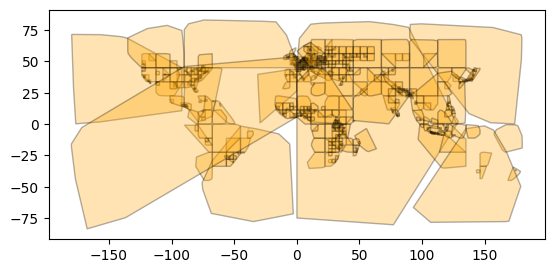

In [17]:
gdf_items.plot(color='orange', edgecolor='k', alpha=.3)